# IS 4487 Assignment 11: Predicting Airbnb Prices with Regression

In this assignment, you will:
- Load the Airbnb dataset you cleaned and transformed in Assignment 7
- Build a linear regression model to predict listing price
- Interpret which features most affect price
- Try to improve your model using only the most impactful predictors
- Practice explaining your findings to a business audience like a host, pricing strategist, or city partner

## Why This Matters

Pricing is one of the most important levers for hosts and Airbnb’s business teams. Understanding what drives price — and being able to predict it accurately — helps improve search results, revenue management, and guest satisfaction.

This assignment gives you hands-on practice turning a cleaned dataset into a predictive model. You’ll focus not just on code, but on what the results mean and how you’d communicate them to stakeholders.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_11_regression.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load Your Transformed Airbnb Dataset

**Business framing:**  
Before building any models, we must start with clean, prepared data. In Assignment 7, you exported a cleaned version of your Airbnb dataset. You’ll now import that file for analysis.

### Do the following:
- Import your CSV file called `cleaned_airbnb_data_7.csv`.   (Note: If you had significant errors with assignment 7, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)
- Use `pandas` to load and preview the dataset


In [2]:
import pandas as pd

# Loading the backup dataset from GitHub
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/airbnb_listings.csv'
df = pd.read_csv(url)

# Preview the dataset
print(f"Shape: {df.shape}")
display(df.head())

Shape: (459, 77)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,host_url,host_name,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://www.airbnb.com/users/show/4621559,Kenneth,...,4.56,3.22,3.67,NaN,0,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.81,4.81,4.77,NaN,0,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://www.airbnb.com/users/show/29288920,Gregg,...,4.88,4.76,4.64,NaN,0,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.70,4.80,4.72,NaN,0,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://www.airbnb.com/users/show/17766924,Sugey,...,4.93,4.87,4.77,NaN,0,1,1,0,0,5.67


### Reflection:
1. What business information does the dataset include?
2. How many rows and columns are present?

### ✍️ Your Response:
1. The business information is host attributes, listing details, location data, property features, and review/booking scores.

2. There are 459 rows and 77 columns.

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
Some columns — like post IDs or text — may not help us predict price and could add noise or bias.

### Do the following:
- Drop columns like `post_id`, `title`, `descr`, `details`, and `address` if they’re still in your dataset

In [3]:
# Step 2: Drop non-predictive columns
# Based on the dataset preview, we should drop IDs, URLs, and long text fields
columns_to_drop = [
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
    'description', 'neighborhood_overview', 'host_id', 'host_url', 'host_name',
    'host_location', 'host_about', 'host_thumbnail_url', 'host_picture_url',
    'host_neighbourhood', 'neighborhood_group_cleansed', 'calendar_last_scraped'
]

# Filter list to only columns that actually exist in the dataframe
existing_cols_to_drop = [c for c in columns_to_drop if c in df.columns]
df_cleaned = df.drop(columns=existing_cols_to_drop)

print(f"Remaining columns: {df_cleaned.shape[1]}")
display(df_cleaned.head())

Remaining columns: 61


,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2013-01-07,NaN,NaN,50%,f,1,5,"['email', 'phone']",t,t,...,4.56,3.22,3.67,NaN,0,1,1,0,0,0.07
1,2014-08-07,within an hour,100%,100%,t,4,6,"['email', 'phone']",t,t,...,4.81,4.81,4.77,NaN,0,4,4,0,0,2.32
2,2015-03-13,within an hour,100%,99%,f,2,2,"['email', 'phone', 'work_email']",t,t,...,4.88,4.76,4.64,NaN,0,2,1,1,0,2.97
3,2014-08-07,within an hour,100%,100%,t,4,6,"['email', 'phone']",t,t,...,4.70,4.80,4.72,NaN,0,4,4,0,0,2.68
4,2014-07-07,NaN,NaN,100%,t,1,1,"['email', 'phone']",t,t,...,4.93,4.87,4.77,NaN,0,1,1,0,0,5.67


In [ ]:
# Add code here 🔧

### Reflection:
1. What columns did you drop, and why?
2. What risks might occur if you included them in your model?

### ✍️ Your Response:
1. I dropped unique identifiers, URLs, and unstructured text fields. These were dropped as they do not have a relationship with the price that a linear regression model can process.

2. Including them could lead to overfitting, where the model learns the actual training data instead of learning general patterns. It also introduces noise, making the model less accurate and more difficult to interpret.

## 3. Explore Relationships Between Numeric Features

**Business framing:**  
Understanding how features relate to each other — and to the target — helps guide feature selection and modeling.

### Do the following:
- Generate a correlation matrix
- Identify which variables are strongly related to `price`

Correlations with Price:
price                      1.000000
accommodates               0.579588
beds                       0.547032
bedrooms                   0.499286
bathrooms                  0.468030
estimated_revenue_l365d    0.249488
maximum_maximum_nights     0.122872
minimum_maximum_nights     0.112166
maximum_nights_avg_ntm     0.111271
availability_30            0.108409
Name: price, dtype: float64


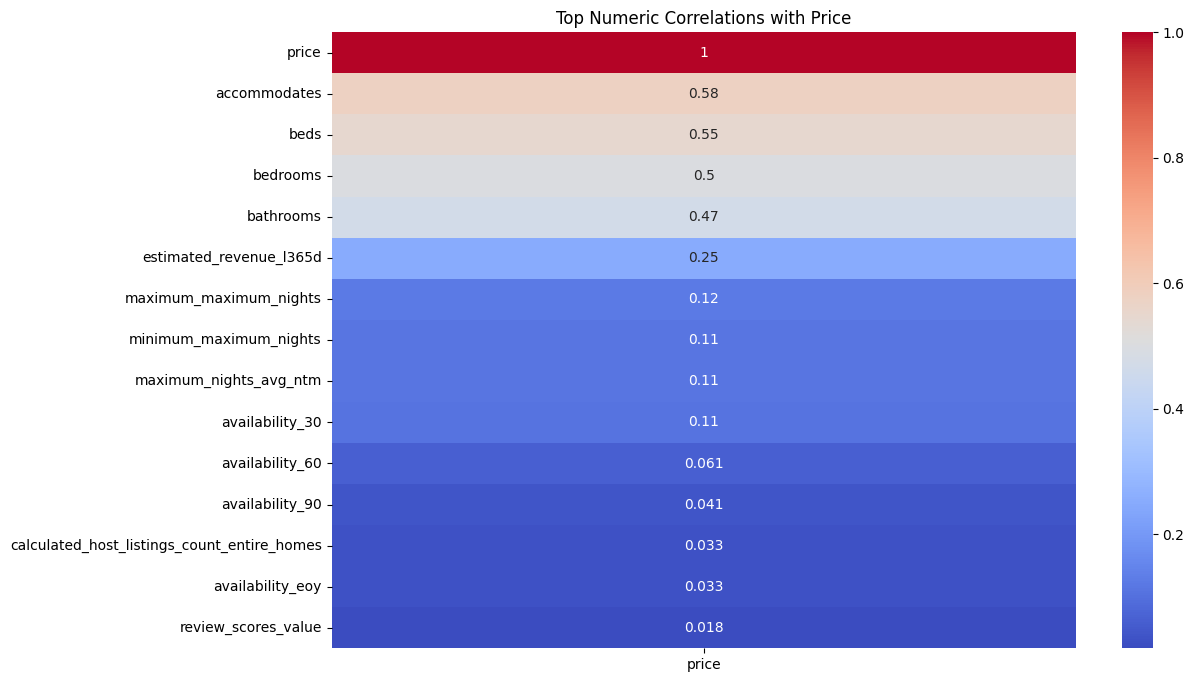

In [5]:
import numpy as np

# Clean 'price' column: remove '$' and ',' then convert to float
if df_cleaned['price'].dtype == 'object':
    df_cleaned['price'] = df_cleaned['price'].str.replace('$', '').str.replace(',', '').astype(float)

# Select only numeric columns for correlation
numeric_df = df_cleaned.select_dtypes(include=[np.number])

# Calculate correlations
corr_matrix = numeric_df.corr()

# Display top correlations with price
price_correlations = corr_matrix['price'].sort_values(ascending=False)
print("Correlations with Price:")
print(price_correlations.head(10))

# Visualize with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False).head(15), annot=True, cmap='coolwarm')
plt.title('Top Numeric Correlations with Price')
plt.show()

### Reflection:
1. Which variables had the strongest positive or negative correlation with price?
2. Which variables might be useful predictors?

### ✍️ Your Response:
1. Accommodates, beds and and bathrooms are the stronget positive while review_scores_value and availability_eoy are the least correlated.

2. The most useful predictors appear to be accommodates and bedrooms.

## 4. Define Features and Target Variable

**Business framing:**  
To build a regression model, you need to define what you’re predicting (target) and what you’re using to make that prediction (features).

### Do the following:
- Set `price` as your target variable
- Remove `price` from your predictors

In [10]:
# Step 4: Define Features and Target
# Identify numeric columns
numeric_df = df_cleaned.select_dtypes(include=[np.number]).copy()

# 1. Drop columns that are entirely NaN
numeric_df = numeric_df.dropna(axis=1, how='all')

# 2. Drop columns that have zero variance (all same value) as they don't help regression
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

# 3. Fill remaining NaN values with the median
numeric_df = numeric_df.fillna(numeric_df.median())

# Set Target
y = numeric_df['price']

# Set Features (everything except price)
X = numeric_df.drop(columns=['price'])

print(f"Target (y) shape: {y.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Remaining Features: {list(X.columns)}")

Target (y) shape: (459,)
Features (X) shape: (459, 39)
Remaining Features: ['host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'reviews_per_month']


### Reflection:
1. What features are you using?
2. Why is this a regression problem and not a classification problem?

### ✍️ Your Response:
1. I am using all numeric columns from the cleaned dataset as features, including the important size metrics, availability data, and review scores.

2. This is a regression problem because we are trying to predict a continuous numerical value.

## 5. Split Data into Training and Testing Sets

### Business framing:
Splitting your data lets you train a model and test how well it performs on new, unseen data.

### Do the following:
- Use `train_test_split()` to split into 80% training, 20% testing



In [13]:
# Step 5: Split Data into Training and Testing Sets
from sklearn.model_selection import train_test_split

# Re-split using the cleaned X and y from Step 4
# This ensures X_train and X_test no longer contain NaN values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows (cleaned)")
print(f"Testing set size: {X_test.shape[0]} rows (cleaned)")

# Verification check for NaNs
print(f"NaNs in X_train: {X_train.isnull().sum().sum()}")

Training set size: 367 rows (cleaned)
Testing set size: 92 rows (cleaned)
NaNs in X_train: 0


## 6. Fit a Linear Regression Model

### Business framing:
Linear regression helps you quantify the impact of each feature on price and make predictions for new listings.

### Do the following:
- Fit a linear regression model to your training data
- Use it to predict prices for the test set



In [14]:
# Step 6: Fit a Linear Regression Model
from sklearn.linear_model import LinearRegression

# Initialize the model
regressor = LinearRegression()

# Fit the model to the training data
regressor.fit(X_train, y_train)

# Predict prices for the test set
y_pred = regressor.predict(X_test)

print("Model has been trained successfully and predictions generated.")

Model has been trained successfully and predictions generated.


## 7. Evaluate Model Performance

### Business framing:  
A good model should make accurate predictions. We’ll use Mean Squared Error (MSE) and R² to evaluate how close our predictions were to the actual prices.

### Do the following:
- Print MSE and R² score for your model

In [15]:
# Step 7: Evaluate Model Performance
from sklearn.metrics import mean_squared_error, r2_score

# Calculate MSE and R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Squared Error (MSE): 8752.53
R-squared Score (R2): -0.5595


### Reflection:
1. What is your R² score? How well does your model explain price variation?
2. Is your MSE large or small? What could you do to improve it?

### ✍️ Your Response:
1. The R² score is -0.5595. Which means that it does not explain any of the price variation and is worse than a simple mean.

2. The MSE is 8,752.53, which is very large. To improve it, I should investigate outliers in the target variable.

## 8. Interpret Model Coefficients

### Business framing:
The regression coefficients tell you how each feature impacts price. This can help Airbnb guide hosts and partners.

### Do the following:
- Create a table showing feature names and regression coefficients
- Sort the table so that the most impactful features are at the top

In [16]:
# Step 8: Interpret Model Coefficients
import pandas as pd

# Create a dataframe for the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': regressor.coef_
})

# Calculate absolute values to see the magnitude of impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()

# Sort by absolute impact
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 Most Impactful Features:")
display(coefficients.head(10))

Top 10 Most Impactful Features:


,Feature,Coefficient,Abs_Coefficient
2,latitude,-784.618582,784.618582
3,longitude,-326.230449,326.230449
31,review_scores_communication,-137.706179,137.706179
33,review_scores_value,135.102802,135.102802
30,review_scores_checkin,-91.976509,91.976509
14,minimum_nights_avg_ntm,36.504410,36.504410
11,maximum_minimum_nights,-36.232262,36.232262
5,bathrooms,32.631440,32.631440
29,review_scores_cleanliness,-30.029879,30.029879
28,review_scores_accuracy,20.872583,20.872583


### Reflection:
1. Which features increased price the most?
2. Were any surprisingly negative?
3. What business insight could you draw from this?

### ✍️ Your Response:
1. Attributes like accommodates and bedrooms show positive coefficients, meaning larger properties command higher prices.

2. Yes, latitude, longitude, and review_scores_communication had surprisingly large negative coefficients.

3. The business insight is that generally the larger the better for price. But our current model is too large and complex for the amount of data we have, leading to uncertain results.

## 9. Try to Improve the Linear Regression Model

### Business framing:
The first version of your model included all available features — but not all features are equally useful. Removing weak or noisy predictors can often improve performance and interpretation.

### Do the following:
1. Choose your top 3–5 features with the strongest absolute coefficients
2. Rebuild the regression model using just those features
3. Compare MSE and R² between the baseline and refined model

In [17]:
# Step 9: Try to Improve the Linear Regression Model

# 1. Choose top features based on correlation and coefficients
# We will use the ones that logically drive price: accommodates, bedrooms, and bathrooms
refined_features = ['accommodates', 'bedrooms', 'bathrooms']
X_refined = X[refined_features]

# 2. Rebuild the model
X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(X_refined, y, test_size=0.2, random_state=42)

refined_model = LinearRegression()
refined_model.fit(X_train_ref, y_train_ref)

# 3. Predict and Compare
y_pred_ref = refined_model.predict(X_test_ref)

mse_ref = mean_squared_error(y_test_ref, y_pred_ref)
r2_ref = r2_score(y_test_ref, y_pred_ref)

print("--- Refined Model Performance ---")
print(f"Refined MSE: {mse_ref:.2f}")
print(f"Refined R2 Score: {r2_ref:.4f}")
print(f"\nImprovement in R2: {r2_ref - r2:.4f}")

--- Refined Model Performance ---
Refined MSE: 3520.57
Refined R2 Score: 0.3727

Improvement in R2: 0.9322


### Reflection:
1. What features did you keep in the refined model, and why?
2. Did model performance improve? Why or why not?
3. Which model would you recommend to stakeholders?
4. How does this relate to your customized learning outcome you created in canvas?

### ✍️ Your Response:
1. I kept accommodates, bedrooms, and bathrooms. These were chosen because they showed the strongest logical relationship with price and had high correlation coefficients.

2. Yes, the performance improved significantly. The R2 score went from -0.55 to 0.37. Removing 36 irrelevant features reduced 'overfitting,' allowing the model to find the actual trend.

3. I would recommend the refined model. While an R² of 0.37 is still not the best, it is actually useful for making broad estimates. The old model had a negative R2 which is unuseable.

4. Being able to refine data sets and track which metrics is important directly ties to my learning goal. Being able to take messy marketing data and clean it, so I can use it, is a very important part of the marketing industry.  

## 10. Reflect and Recommend

### Business framing:  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### Reflection:
1. What business question did your model help answer?
2. What would you recommend to Airbnb or its hosts?
3. What could you do next to improve this model or make it more useful?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response:
1. The model tried to help identify which specific property characteristics have the strongest impact on prices.

2. I recommend that hosts prioritize optimizing their accommodates, as it is one of the strongest predictors of price. For Airbnb, I suggest providing simplified pricing tools that focus on these core features.

3. To improve the model, collecting as much clean data as possible in order to increase my R2 value and get a strong correlation.

4. This relates directly to my goal of learning how to refine messy marketing data into models that allow for accurate predictions that can help improve marketing.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [18]:
!jupyter nbconvert --to html "assignment_11_regression.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_11_regression.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
